In [1]:
import sys, os
import pathlib

root = pathlib.Path("../src").resolve()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from mltools         import MLConfig
from mltools.shared.logging import setup_logging

from mltools.data.loader import DataLoader

config = MLConfig.from_yaml("../configs/ml_config.yaml")
setup_logging(log_level=config.project.log_level,
              experiment=config.project.name)

TARGET    = config.data.target_column
ID_COLS   = config.data.id_columns
DATE_COLS = config.data.date_columns             

df = DataLoader.load("../data/raw/dataset_full.csv")


d:\ml_pipeline\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


04:08:22 | INFO     | mltools.data.loader:64 | Loading data dari ../data/raw/dataset_full.csv (format: .csv)
04:08:23 | SUCCESS  | mltools.data.loader:101 | Data loaded: 88,647 rows × 112 cols | 79.4 MB


Splitting

In [2]:
from mltools.preprocessing.splitter import ExpertDataSplitter, check_data_leakage
from loguru import logger
import numpy as np

df = df.drop_duplicates().reset_index(drop=True) # Menghapus duplicates rows

cols_neg = [c for c in df.columns if df[c].min() == -1]
print(cols_neg)
for col in cols_neg:
    if col in df.columns:
        df[col] = df[col].replace(-1, np.nan) # Mengubah nilai -1 menjadi Nan

df.describe()
X = df.drop(columns=[TARGET] + ID_COLS + DATE_COLS, errors="ignore")
y = df[TARGET]

splitter = ExpertDataSplitter(
    task         = "classification",
    test_size    = 0.15,             
    val_size     = 0.15,              
    strategy     = "holdout",         
    random_state = 42,
)

X_train, X_val, X_test, y_train, y_val, y_test = splitter.split_holdout(X, y)

logger.info(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
has_leak = check_data_leakage(X_train, X_test)
if has_leak:
    raise RuntimeError("Leakage terdeteksi!")

['qty_dot_directory', 'qty_hyphen_directory', 'qty_underline_directory', 'qty_slash_directory', 'qty_questionmark_directory', 'qty_equal_directory', 'qty_at_directory', 'qty_and_directory', 'qty_exclamation_directory', 'qty_space_directory', 'qty_tilde_directory', 'qty_comma_directory', 'qty_plus_directory', 'qty_asterisk_directory', 'qty_hashtag_directory', 'qty_dollar_directory', 'qty_percent_directory', 'directory_length', 'qty_dot_file', 'qty_hyphen_file', 'qty_underline_file', 'qty_slash_file', 'qty_questionmark_file', 'qty_equal_file', 'qty_at_file', 'qty_and_file', 'qty_exclamation_file', 'qty_space_file', 'qty_tilde_file', 'qty_comma_file', 'qty_plus_file', 'qty_asterisk_file', 'qty_hashtag_file', 'qty_dollar_file', 'qty_percent_file', 'file_length', 'qty_dot_params', 'qty_hyphen_params', 'qty_underline_params', 'qty_slash_params', 'qty_questionmark_params', 'qty_equal_params', 'qty_at_params', 'qty_and_params', 'qty_exclamation_params', 'qty_space_params', 'qty_tilde_params', 

Handle Missing Values

In [3]:
from mltools.preprocessing.missing_handler import ExpertMissingHandler, analyze_missing_pattern, validate_no_missing
import pandas as pd

pattern = analyze_missing_pattern(X_train)
with pd.option_context('display.max_rows', None):
    print(pattern)

handler = ExpertMissingHandler(
    drop_col_threshold    = 0.6,          
    drop_row_threshold    = None,         
    num_strategy          = "iterative",  
    add_missing_indicator = True,
)

handler.fit(X_train)

X_train = handler.transform(X_train)
X_val   = handler.transform(X_val)
X_test  = handler.transform(X_test)

binary_indicator_cols = [
    c for c in X_train.columns if c.endswith("_was_missing")
]

validate_no_missing(X_train)

                        column  n_missing pct_missing    dtype  \
51           qty_dollar_params      55943       91.6%  float64   
50          qty_hashtag_params      55943       91.6%  float64   
38        qty_underline_params      55943       91.6%  float64   
39            qty_slash_params      55943       91.6%  float64   
49         qty_asterisk_params      55943       91.6%  float64   
48             qty_plus_params      55943       91.6%  float64   
45            qty_space_params      55943       91.6%  float64   
44      qty_exclamation_params      55943       91.6%  float64   
47            qty_comma_params      55943       91.6%  float64   
46            qty_tilde_params      55943       91.6%  float64   
42               qty_at_params      55943       91.6%  float64   
43              qty_and_params      55943       91.6%  float64   
41            qty_equal_params      55943       91.6%  float64   
40     qty_questionmark_params      55943       91.6%  float64   
53        

d:\ml_pipeline\.venv\lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


04:10:00 | SUCCESS  | mltools.preprocessing.missing_handler:305 | ✅ Tidak ada missing values tersisa!


True

Handle Outlier

04:10:08 | INFO     | mltools.preprocessing.outlier_handler:61 | Fitting outlier handler: method=iqr, treatment=cap
04:10:08 | SUCCESS  | mltools.preprocessing.outlier_handler:76 | OutlierHandler fitted pada 66 kolom
                  column  n_outliers pct_outliers  lower_bound  upper_bound  \
0            qty_dot_url       24272       39.76%       2.0000       2.0000   
51     qty_asterisk_file       23419       38.36%      -0.0013       0.0016   
33   qty_tilde_directory       21162       34.67%      -0.0075       0.0124   
52      qty_percent_file       21012       34.42%      -0.0083       0.0138   
48        qty_tilde_file       20964       34.34%      -0.0037       0.0034   
..                   ...         ...          ...          ...          ...   
21  qty_underline_domain          44        0.07%       0.0000       0.0000   
13      qty_asterisk_url          41        0.07%       0.0000       0.0000   
15        qty_dollar_url          32        0.05%       0.0000       0.0

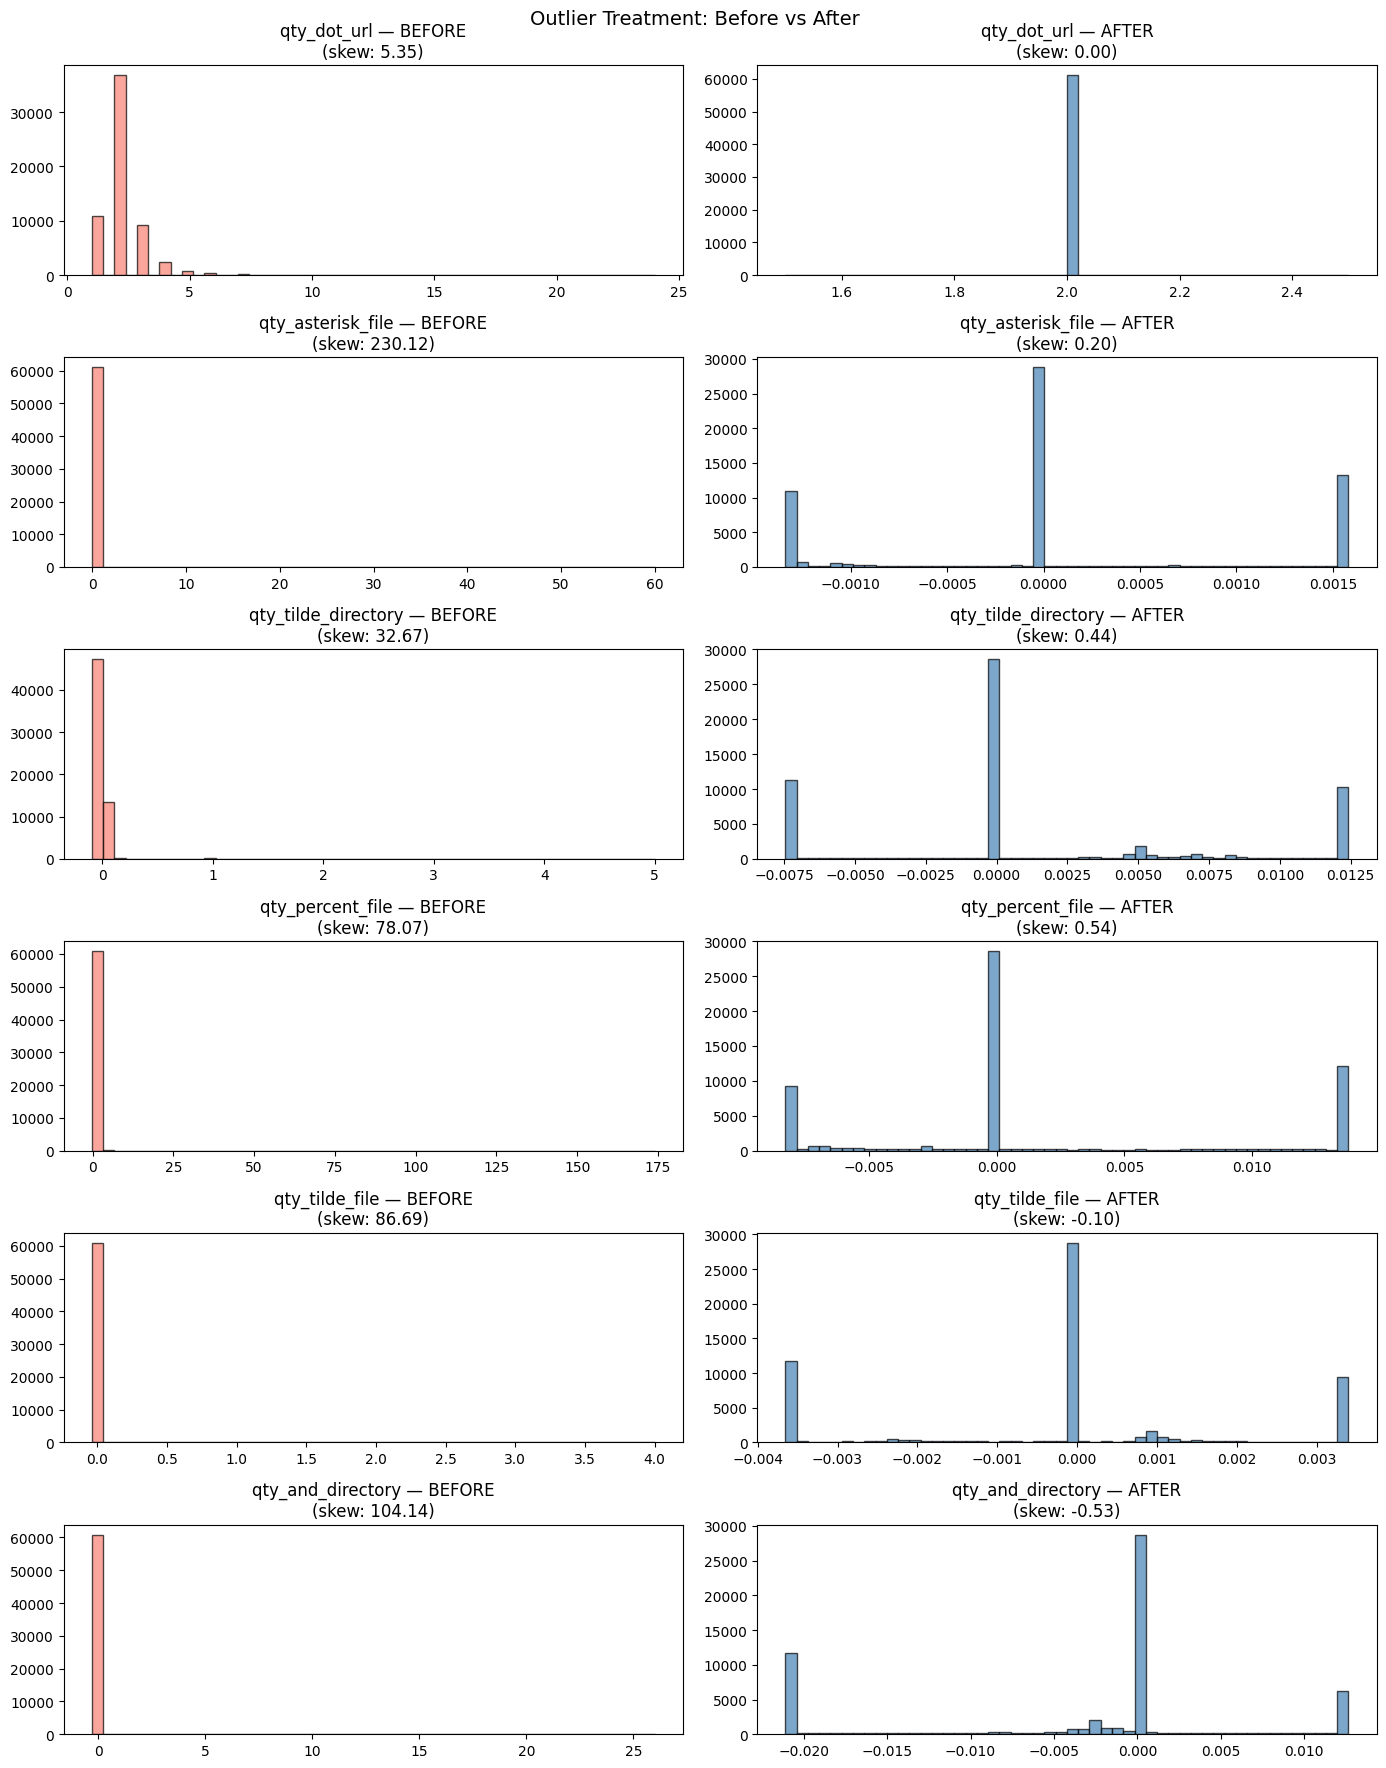

In [4]:
from mltools.preprocessing.outlier_handler import ExpertOutlierHandler, plot_outlier_before_after

all_num_cols   = X_train.select_dtypes(include="number").columns.tolist()

exclude_outlier = [
    c for c in all_num_cols
    if c.endswith("_was_missing")                              # Flag missing
    or c.endswith("_bin")                                      # Bin features (nanti)
    or set(X_train[c].dropna().unique()).issubset({0, 1})      # Binary apapun
]

cols_for_outlier = [c for c in all_num_cols if c not in exclude_outlier]

handler_out = ExpertOutlierHandler(
    method   = "iqr",
    treatment= "cap",
    threshold= 1.5,
    columns  = cols_for_outlier
)
handler_out.fit(X_train)

report_out = handler_out.get_outlier_report(X_train)
print(report_out)

X_train_before = X_train.copy()   # simpan untuk visualisasi
X_train = handler_out.transform(X_train)
X_val   = handler_out.transform(X_val)
X_test  = handler_out.transform(X_test)

plot_outlier_before_after(
    X_train_before, X_train,
    columns=report_out["column"].head(6).tolist()
)


Export ke folder Interim

In [6]:
import joblib
import json
from pathlib import Path


# ensure target directories exist to avoid FileNotFoundError
interim_dir = Path("../data/interim")
preproc_dir = Path("../models/preprocessing")
interim_dir.mkdir(parents=True, exist_ok=True)
preproc_dir.mkdir(parents=True, exist_ok=True)

X_train.to_parquet(interim_dir / "X_train_clean.parquet", index=False)
X_val.to_parquet(  interim_dir / "X_val_clean.parquet",   index=False)
X_test.to_parquet( interim_dir / "X_test_clean.parquet",  index=False)

y_train.to_frame().to_parquet(interim_dir / "y_train_clean.parquet", index=False)
y_val.to_frame().to_parquet(  interim_dir / "y_val_clean.parquet",   index=False)
y_test.to_frame().to_parquet( interim_dir / "y_test_clean.parquet",  index=False)

joblib.dump(handler, preproc_dir / "missing_handler.joblib")
joblib.dump(handler_out, preproc_dir / "outlier_handler.joblib")

meta = {
    "target"              : TARGET,
    "id_columns"          : ID_COLS,
    "date_columns"        : DATE_COLS,
    "cols_dropped_missing": handler.cols_to_drop_,
    "cols_imputed_num"    : handler.num_missing_cols_,
    "binary_indicator_cols": binary_indicator_cols,
    "cols_excluded_outlier": exclude_outlier,
    "outlier_method"      : config.preprocessing.outliers.method,
    "outlier_treatment"   : config.preprocessing.outliers.treatment,
    "shapes": {
        "X_train": list(X_train.shape),
        "X_val"  : list(X_val.shape),
        "X_test" : list(X_test.shape),
    },
}

with open(preproc_dir / "preprocessing_meta.json", "w") as f:
    json.dump(meta, f, indent=2, default=str)

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  PREPROCESSING STEP 1-3 SELESAI")
print("="*55)
print(f"  X_train : {X_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"\n  Data interim  → data/interim/*.parquet")
print(f"  Components    → models/preprocessing/*.joblib")
print(f"  Metadata      → models/preprocessing/preprocessing_meta.json")
print(f"\n  Kolom di-drop (missing > 60%) : {len(handler.cols_to_drop_)}")
print(f"  Kolom _was_missing ditambah   : {len(binary_indicator_cols)}")
print(f"  Kolom dikecualikan outlier    : {len(exclude_outlier)}")
print("="*55)


  PREPROCESSING STEP 1-3 SELESAI
  X_train : (61045, 137)
  X_val   : (13082, 137)
  X_test  : (13082, 137)

  Data interim  → data/interim/*.parquet
  Components    → models/preprocessing/*.joblib
  Metadata      → models/preprocessing/preprocessing_meta.json

  Kolom di-drop (missing > 60%) : 20
  Kolom _was_missing ditambah   : 46
  Kolom dikecualikan outlier    : 71
